# Анализ продуктовых метрик и поведения пользователей в мобильной игре
*Примечание: проект является учебным, анализируемые данные — синтетические.*

## 1. Введение и постановка задач

**Контекст проекта:**  
В этом исследовании мы изучаем поведение игроков в мобильной игре-викторине. Главная цель — понять, как обучение влияет на то, как быстро пользователи проходят ключевые этапы и готовы ли они в итоге тратить деньги на покупки. 

**Каких пользователей мы изучаем:**  
В исследовании участвуют игроки, которые **зарегистрировались в игре в 2018 году**. Все расчеты, графики и проверки в этом проекте выполнены только для этой конкретной группы людей.

**Главные вопросы исследования:**
1. **Скорость прохождения игры:** Отличается ли время прохождения этапов у тех игроков, кто успешно закончил обучение, от тех, кто даже не начинал его?
2. **Влияние повторных обучений на покупки:** Зависит ли вероятность покупки от того, сколько раз пользователь проходил обучение(его можно проходить сколько угодно раз)?
3. **Возвраты к инструкциям:** Как часто игроки начинают обучение уже после того, как выбрали уровень сложности? Если таких людей много, возможно, правила игры или интерфейс им непонятны.

## 2. Предварительная обработка данных и проверка их целостности

В этом разделе проводится проверка исходных данных(`events.csv` — действия игроков и `purchases.csv` — покупки).

### Структура исходных данных

Для анализа доступны две таблицы. Ниже приведено простое описание их содержимого:

**1. Таблица действий игроков (`events.csv`):**
* `id` — уникальный номер записи в таблице.
* `event_type` — тип действия (регистрация, старт обучения, финиш обучения, выбор сложности).
* `selected_level` — выбранный уровень сложности игры (`easy`, `medium`, `hard`).
* `start_time` — дата и время совершения действия.
* `tutorial_id` — номер конкретной сессии обучения.
* `user_id` — уникальный номер игрока.

**2. Таблица покупок (`purchases.csv`):**
* `id` — уникальный номер покупки.
* `user_id` — уникальный номер игрока, совершившего покупку.
* `event_datetime` — дата и время оплаты.
* `amount` — сумма покупки.

*Примечание: Поля `start_time` и `event_datetime` содержат дату и время, когда конкретное действие или покупка были зафиксированы в системе учета игры.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

### 2.1. Оптимизация типов данных и экономия памяти
Переводим числовые типы данных в компактные форматы (исходя из реальных диапазонов чисел в таблицах). Текстовые столбцы с повторяющимися значениями приводим к категориальному типу. Столбцы с датами приводим к правильному временному виду. 
* Такой шаг позволяет уменьшить размер таблиц в оперативной памяти и ускорить выполнение последующего кода.

In [2]:
# Загрузка и обработка данных о действиях пользователей
events_dtypes = {    
    'event_type': 'category',
    'selected_level': 'category',
    'tutorial_id': 'Int32',
    'user_id': 'int32'
}

events = pd.read_csv('data/events.csv', index_col='id', dtype=events_dtypes)
events.index = events.index.astype('int32')

events['start_time'] = pd.to_datetime(events['start_time'], errors='coerce')

# Загрузка и обработка данных о покупках пользователей
purchases_dtypes = {
    'user_id': 'int32',
    'amount': 'int16'
}

purchases = pd.read_csv('data/purchases.csv', index_col='id', dtype=purchases_dtypes)
purchases.index = purchases.index.astype('int16')
purchases['event_datetime'] = pd.to_datetime(purchases['event_datetime'], errors='coerce')

In [3]:
# Оцениваем типы данных, объем памяти и наличие пропусков после базовой конвертации
events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 252334 entries, 28903 to 281236
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   event_type      252334 non-null  category      
 1   selected_level  31086 non-null   category      
 2   start_time      252201 non-null  datetime64[ns]
 3   tutorial_id     125103 non-null  Int32         
 4   user_id         252334 non-null  int32         
dtypes: Int32(1), category(2), datetime64[ns](1), int32(1)
memory usage: 5.5 MB


> Проверка качества заполнения  столбца `start_time`
>
> Заметно расхождение в количестве значений в столбцах:
> * Общее число записей в датафрейме: **252 334**
> * Успешно преобразовано в формат даты: **252 201**
> * Количество образовавшихся пропусков (`NaT`): **133 (0.053%)**
>
> **Вывод:** Появление пропусков после применения `pd.to_datetime()` с параметром `errors='coerce'` показывает наличие ошибок форматирования или логирования в исходном CSV-файле. 
> 
> *В следующей ячейке проведем точечный аудит этих 133 аномалий, чтобы разобраться в природе технического сбоя.*

In [4]:
# 1. Читаем столбец start_time из файла как есть.
raw_time_series = pd.read_csv('data/events.csv', usecols=['id', 'start_time'], index_col='id')['start_time']

# 2. Находим ID строк, которые не распознались как datetime
failed_ids = events[events['start_time'].isna()].index

# 3. Вытаскиваем оригинал этих строк и убираем дубликаты
bad_dates = raw_time_series.loc[failed_ids].to_numpy()
print(f"Найдено ошибок: {len(bad_dates)}")

Найдено ошибок: 133


In [5]:
# Если вам нужно обновить или заново сгенерировать файл bad_dates.txt, раскомментируйте две строки ниже и запустите ячейку:
np.savetxt('bad_dates.txt', bad_dates, fmt='%s')

> 📋 **Заметка по итогам аудита:**
> 
> В ходе проверки мы обнаружили 133 строки с техническими ошибками логирования дат (несуществующий високосный день `2017-02-29`, склеенные годы `20162015-09-18`). 
> 
> **Как мы поступили с этими ошибками:**
> При считывании файлов мы применили метод `pd.to_datetime()` с параметром `errors='coerce'`. Этот инструмент автоматически и принудительно превратил все 133 испорченные строки в пустые пропуски (`NaT`). 
> 
> **Почему это безопасно для исследования:**
> Эти аномалии составляют малую долю — всего **0.053%** от общего объема данных логов (252 334 строки). Такое количество пропусков не исказит наши расчеты, поэтому мы можем безопасно исключить их из дальнейшего анализа.
> 
> Закомментированный в ячейке выше код позволяет автоматически перезаписать или заново сгенерировать этот список на диске. Чтобы не перегружать блокнот сырыми данными, полный список аномалий вынесен в отдельный текстовый файл: **[bad_dates.txt](./bad_dates.txt)**.

In [6]:
# Оцениваем типы данных, объем памяти и наличие пропусков после базовой конвертации
purchases.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 5956 entries, 15674 to 21629
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         5956 non-null   int32         
 1   event_datetime  5956 non-null   datetime64[ns]
 2   amount          5956 non-null   int16         
dtypes: datetime64[ns](1), int16(1), int32(1)
memory usage: 93.1 KB


### 2.2. Анализ одновременных действий

В реальности может встречаться ситуация, когда у одного пользователя фиксируется несколько действий в один и тот же момент времени.  
Далее проводим поиск таких дубликатов

In [7]:
# Ищем полные дубликаты по связке "Пользователь + Время"
valid_time_events = events[events['start_time'].notna()]
user_time_duplicates = valid_time_events[valid_time_events.duplicated(subset=['user_id', 'start_time'], keep=False)]
time_overlap = user_time_duplicates.groupby(['user_id', 'start_time'])['event_type'].apply(list).reset_index()
overlap_table = time_overlap['event_type'].value_counts().reset_index()
overlap_table.columns = ['event_combination', 'occurrences']
overlap_table

,event_combination,occurrences
0,"[tutorial_start, tutorial_start]",4
1,"[tutorial_start, tutorial_finish]",3
2,"[tutorial_finish, tutorial_finish]",1
3,"[tutorial_finish, pack_choice]",1


> **Результаты анализа одновременных действий:**
>
> Проверка выявила **9 случаев** наложения событий по времени.
>
> **Решение:**
> Обнаруженные наложения составляют менее **0.004%** от объема данных. Они не повлияют на расчеты, поэтому удаление этих строк не требуется.

### 2.3. Проверка ссылочной целостности

Проверяем, нет ли в таблице продаж (`purchases`) пользователей, у которых в таблице действий (`events`) отсутствует даже факт регистрации или захода в игру.

In [8]:
# Получаем уникальные ID пользователей из обеих таблиц
unique_event_users = events['user_id'].unique()
unique_purchase_users = purchases['user_id'].unique()

# Ищем пользователей, которые есть в покупках, но отсутствуют в событиях
missing_users = purchases[~purchases['user_id'].isin(unique_event_users)]['user_id'].unique()
print(f'Пользователей отсутсвующих в логах событий: {len(missing_users)}\n')

Пользователей отсутсвующих в логах событий: 0



**Итог проверки:**
Все пользователи, совершившие покупки, присутствуют в логах активности игры.

### 2.4. Синхронизация временных рамок действий и продаж

Чтобы расчеты конверсий были точными, временные рамки в обеих таблицах должны полностью совпадать. Если платежный шлюз продолжал фиксировать покупки после того, как игра перестала записывать действия игроков, метрики будут искусственно завышены (деньги в логах есть, а пользователей за эти дни нет).  
Выводим минимальные и максимальные даты для обоих датафреймов, чтобы проверить их синхронность.

In [9]:
print(f"Логи действий: {events['start_time'].min()} - {events['start_time'].max()}")
print(f"Логи покупок: {purchases['event_datetime'].min()} - {purchases['event_datetime'].max()}\n")

Логи действий: 2016-05-11 23:40:55 - 2020-07-02 13:36:36
Логи покупок: 2016-05-12 10:34:16 - 2020-07-08 01:59:21



> ⚠️ **Временной разрыв**
>
> * Логи действий игроков (`events`)  заканчиваются **2020-07-02 13:36:36**
> * Логи продаж (`purchases`) продолжают записываться до **2020-07-08 01:59:21**
>
> **Вывод:** Возможно, имеет место технический сбой выгрузки или прекращение логирования внутриигровых действий на 6 дней раньше окончания фиксации оплат. Использование данных за период с 2 по 8 июля может привести к искажению расчетов.
>
> **Решение:** 
>  Данные о продажах будут ограничены последней датой логов действий пользователей (`<= 2020-07-02 13:36:36`).

In [10]:
max_event_time = events['start_time'].max()

# Проверяем, есть ли в таблице покупки, выходящие за временные рамки логов действий
out_of_bounds_purchases = purchases[purchases['event_datetime'] > max_event_time]

if len(out_of_bounds_purchases) > 0:
    deleted_count = len(out_of_bounds_purchases)
    purchases = purchases[purchases['event_datetime'] <= max_event_time]
    print(f"Синхронизация выполнена успешно. Удалено покупок из «слепого» периода: {deleted_count}")
else:
    print("Синхронизация уже была произведена ранее. Данные находятся в актуальном состоянии.")

Синхронизация выполнена успешно. Удалено покупок из «слепого» периода: 21


### 2.5. Проверка пользователей на повторные регистрации

Cчитаем количество регистраций для каждого игрока и смотрим на среднее значение по всей таблице. В идеальном датасете среднее число регистраций на человека должно быть строго равно единице.

In [11]:
# Проверка на множественную регистрацию пользователей
float(events[events['event_type'] == 'registration']['user_id'].value_counts().mean())

1.0

**Итог проверки:**
Код вернул значение **`1.0`**. Это означает, что каждый пользователь в нашей выборке зарегистрирован в системе ровно один раз. Дубликаты учетных записей отсутствуют

### 2.6. Логический тест хронологии действий

Проверяем на наличие пользователей, у которых какие-либо действия зафиксированы **раньше**, чем регистрация.

In [12]:
# 1. Находим время регистрации для каждого пользователя
user_reg_time = events[events['event_type'] == 'registration'].groupby('user_id')['start_time'].min()

# 2. Находим время самого первого действия для каждого пользователя
user_first_action_time = events.groupby('user_id')['start_time'].min()

# 3. Объединяем эти данные в один проверочный датафрейм по user_id
chronology_check = pd.DataFrame({
    'reg_time': user_reg_time,
    'first_action_time': user_first_action_time
})

# 4. Ищем строки, где первое действие зафиксировано РАНЬШЕ регистрации
anomal_chronology = chronology_check[chronology_check['first_action_time'] < chronology_check['reg_time']]

print(f"Количество пользователей с действиями зафиксированными ДО регистрации: {len(anomal_chronology)}")

Количество пользователей с действиями зафиксированными ДО регистрации: 0


**Итог проверки:**
Код не обнаружил ни одного пользователя с нарушением хронологии. Для 100% игроков регистрация является стартовой точкой взаимодействия с игрой.

### 2.7. Формирование целевой группы исследования (Когорта 2018 года)

Все предыдущие шаги проверки проводились на полном массиве данных. Теперь исходные таблицы приведены к порядку. Выделяем группу пользователей, зарегистрировавшихся в **2018 году**.


In [13]:
# 1. Находим строки с регистрацией в 2018 году
registrations_2018 = events[
    (events['event_type'] == 'registration') & 
    (events['start_time'].between('2018-01-01', '2018-12-31 23:59:59'))
]

# 2. Извлекаем уникальные ID этих пользователей
cohort_2018_users = registrations_2018['user_id'].unique()

# 3. Фильтруем ОСНОВНЫЕ датафреймы, оставляя только пользователей из нужной когорты
events = events[events['user_id'].isin(cohort_2018_users)]
purchases = purchases[purchases['user_id'].isin(cohort_2018_users)]

print(f"Размер когорты (уникальных пользователей, зарегистрированных в 2018 году): {len(cohort_2018_users)}")
print(f"Осталось строк в таблице действий (events): {len(events)}")
print(f"Осталось строк в таблице покупок (purchases): {len(purchases)}")

Размер когорты (уникальных пользователей, зарегистрированных в 2018 году): 19926
Осталось строк в таблице действий (events): 66959
Осталось строк в таблице покупок (purchases): 1600


**Итог предобработки:**
Целевая группа игроков успешно сформирована. В выборке осталось **19 926 уникальных пользователей**, зарегистрированных в 2018 году.

> 🎯 **Методология сегментации: Фокус на чистых шаблонах поведения**
>
> При сравнительном анализе скоростей прохождения этапов из финального расчета намеренно исключена промежуточная группа пользователей — *«Начали, но не закончили обучение»*. 
>
> **Зачем это сделано (Аналитическое обоснование):**
> Данный сегмент является пограничным и неоднородным. В него могут входить как игроки, которые бросили туториал из-за скуки/непонимания и потеряли интерес к игре, так и те, кто разобрались в интерфейсе, закрыли подсказки и приступили. 
> 
> Исключение этой «серой зоны» позволяет нам сопоставить два **максимально контрастных и чистых сценария**:
> 1. Полноценное и успешное погружение в контекст игры через туториал (*«Завершили обучение»*).
> 2. Полное осознанное или интуитивное игнорирование подсказок (*«Не начинали обучение»*).

## 3. Влияние обучения на скорость прохождения игровых этапов  
Здесь мы проверяем, как успешное прохождение обучения влияет на то, сколько времени тратит игрок на ключевые действия в приложении.

### 3.1. Разделение пользователей на группы. Расчет медианного времени прохождения этапов для каждой группы

1. Те, кто полностью и успешно закончил обучение (`tutorial_finish`).
2. Те, кто вообще не начинал его (у них нет ни одного события `tutorial_start`).

Намеренно исключаем промежуточную группу игроков, которые начали обучение, но не закончили его. Их поведение неоднородно и может размыть метрики. Наша цель — сравнить два максимально контрастных сценария. Посчитаем медианное время в часах от момента регистрации до выбора уровня сложности и до выбора пакета покупок, чтобы оценить скорость вовлечения пользователей.

In [14]:
# 1. Выделяем группы пользователей
users_started_tut = set(events[events['event_type'] == 'tutorial_start']['user_id'])
users_finished_tut = set(events[events['event_type'] == 'tutorial_finish']['user_id'])

# Группа "Без обучения" (даже не начинали)
group_no_tutorial = set(events['user_id']) - users_started_tut

# Группа "Прошли обучение"
group_with_tutorial = users_finished_tut

# 2. Создаем базовую таблицу со временем первого наступления каждого события для пользователей
user_timestamps = (
    events.groupby(['user_id', 'event_type'], observed=False)['start_time']
    .min()
    .unstack()
)

# 3. Рассчитываем время прохождения этапов от момента регистрации (в часах)
user_timestamps['time_to_level_choice'] = (
    (user_timestamps['level_choice'] - user_timestamps['registration']).dt.total_seconds() / 3600
)
user_timestamps['time_to_pack_choice'] = (
    (user_timestamps['pack_choice'] - user_timestamps['registration']).dt.total_seconds() / 3600
)

# 4. Добавляем признак группы
def user_segmentation(user_id):
    if user_id in group_with_tutorial:
        return 'Завершили обучение'
    elif user_id in group_no_tutorial:
        return 'Не начинали обучение'
    return 'Начали, но не закончили'

user_timestamps['group'] = user_timestamps.index.map(user_segmentation)

# 5. Считаем медианное время для групп (медиана устойчива к выбросам, в отличие от среднего)
metrics_compare = (
    user_timestamps[user_timestamps['group'].isin(['Завершили обучение', 'Не начинали обучение'])]
    .groupby('group')[['time_to_level_choice', 'time_to_pack_choice']]
    .median()
    .round(2)
)

metrics_compare.columns = ['Медиана времени до выбора уровня сложности (ч)', 'Медиана времени до выбора пакета (ч)']
display(metrics_compare)

,Медиана времени до выбора уровня сложности (ч),Медиана времени до выбора пакета (ч)
group,,
Завершили обучение,6.00,6.10
Не начинали обучение,4.93,4.77


> 📊 **Вывод:**
>
> Результаты расчета медианного времени показывают различие в поведении сегментов:
>
> 1. **Обученные пользователи следуют ожидаемому пути:** Они демонстрируют последовательное линейное поведение. Тратят больше времени на знакомство с игрой, но быстро переходят к выбору пакета.
> 2. **Необученные пользователи движутся быстрее:** Они достигают ключевых экранов быстрее.

Видимая в таблице разница выглядит многообещающе. Однако на имеющейся выборке эти различия могут оказаться случайным шумом. Чтобы доказать, что обучение действительно меняет скорость прохождения этапов игры, необходимо подтвердить статистическую значимость различий. 

### 3.2. Визуализация распределения

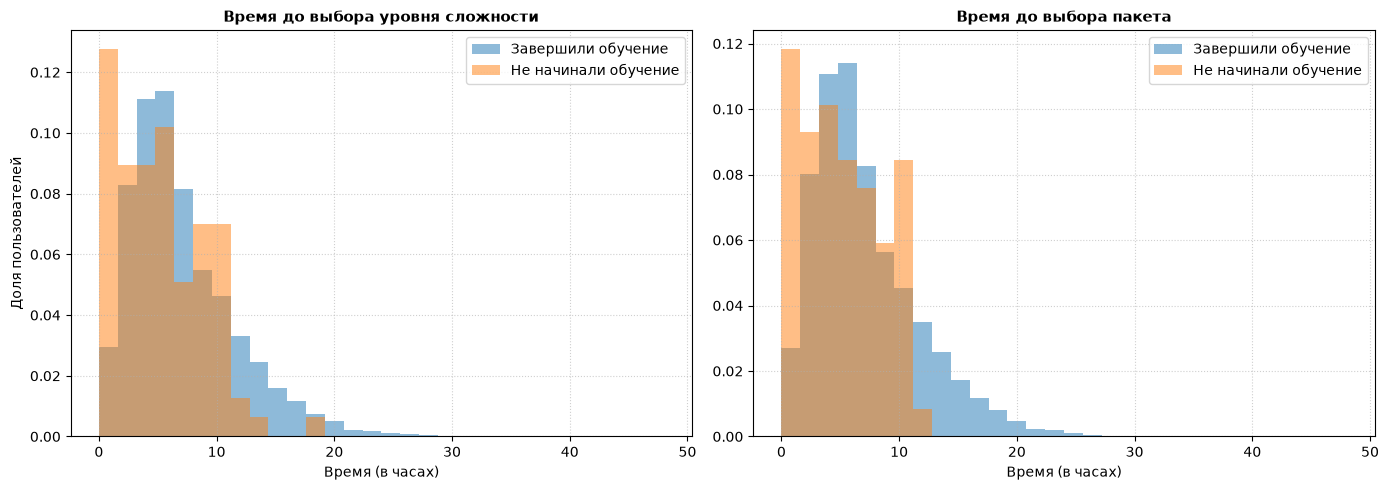

In [15]:
# 1. Создаем общее полотно и сетку осей: 1 строка, 2 колонки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- ЛЕВЫЙ ГРАФИК: Время до выбора уровня (ax1) ---
user_timestamps[user_timestamps['group'] == 'Завершили обучение']['time_to_level_choice'].hist(
    bins=30, range=(0, 48), alpha=0.5, label='Завершили обучение', density=True, ax=ax1
)
user_timestamps[user_timestamps['group'] == 'Не начинали обучение']['time_to_level_choice'].hist(
    bins=30, range=(0, 48), alpha=0.5, label='Не начинали обучение', density=True, ax=ax1
)
ax1.set_title('Время до выбора уровня сложности', fontsize=11, fontweight='bold')
ax1.set_xlabel('Время (в часах)')
ax1.set_ylabel('Доля пользователей')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# --- ПРАВЫЙ ГРАФИК: Время до выбора пакета (ax2) ---
user_timestamps[user_timestamps['group'] == 'Завершили обучение']['time_to_pack_choice'].hist(
    bins=30, range=(0, 48), alpha=0.5, label='Завершили обучение', density=True, ax=ax2
)
user_timestamps[user_timestamps['group'] == 'Не начинали обучение']['time_to_pack_choice'].hist(
    bins=30, range=(0, 48), alpha=0.5, label='Не начинали обучение', density=True, ax=ax2
)
ax2.set_title('Время до выбора пакета', fontsize=11, fontweight='bold')
ax2.set_xlabel('Время (в часах)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

> Визуальный анализ гистограмм распределения плотности подтверждает две важные особенности данных:
> * Распределения времени на обоих этапах имеют правостороннюю асимметрию. Большинство игроков принимает решения быстро, но единицы задерживаются на дни.
> * Данные **не соответствуют критерию нормальности**, необходимому для классического Т-теста Стьюдента.
>
> **Решение:** Для строгого доказательства гипотезы используем **критерий Манна-Уитни**

### 3.3. Статистический тест

In [16]:
# Формируем чистые выборки времени для теста (без пропусков)
time_lvl_with_tut = user_timestamps[user_timestamps['group'] == 'Завершили обучение']['time_to_level_choice'].dropna()
time_lvl_no_tut = user_timestamps[user_timestamps['group'] == 'Не начинали обучение']['time_to_level_choice'].dropna()
time_pack_with_tut = user_timestamps[user_timestamps['group'] == 'Завершили обучение']['time_to_pack_choice'].dropna()
time_pack_no_tut = user_timestamps[user_timestamps['group'] == 'Не начинали обучение']['time_to_pack_choice'].dropna()

print(f'Размеры групп: Завершили обучение {len(time_lvl_with_tut)} пользователей; Не начинали обучение {len(time_lvl_no_tut)} пользователей.')
print(f'Размеры групп: Завершили обучение {len(time_pack_with_tut)} пользователей; Не начинали обучение {len(time_pack_no_tut)} пользователей.')

Размеры групп: Завершили обучение 7501 пользователей; Не начинали обучение 98 пользователей.
Размеры групп: Завершили обучение 5176 пользователей; Не начинали обучение 74 пользователей.


> ⚠️ **Примечание (Дисбаланс выборок)**
>
> Наблюдается сильный дисбаланс сегментов. 
> Критерий Манна-Уитни выбран, так как он устойчив к разнице в размерах выборок. Однако малый объем группы без обучения снижает общую мощность теста, поэтому критерий сможет зафиксировать только действительно фундаментальные различия в поведении игроков.

In [17]:
# --- ТЕСТ 1: Время от регистрации до выбора уровня сложности ---
# Запускаем двусторонний тест Манна-Уитни
_, p_value_lvl = stats.mannwhitneyu(time_lvl_with_tut, time_lvl_no_tut, alternative='two-sided')

# --- ТЕСТ 2: Время от регистрации до выбора пакета ---
# Запускаем двусторонний тест Манна-Уитни
_, p_value_pack = stats.mannwhitneyu(time_pack_with_tut, time_pack_no_tut, alternative='two-sided')


print("===============================================================")
print("  РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ (Уровень значимости alpha = 0.05)")
print("===============================================================")

print(f"1. Время до выбора уровня сложности:")
print(f"   -> Размеры групп: Обученные = {len(time_lvl_with_tut)} | Без обучения = {len(time_lvl_no_tut)}")
print(f"   -> p-value: {p_value_lvl}")
print(f"   -> Вердикт: {'ОТКЛОНЯЕМ H0 (Разница статистически значима)' if p_value_lvl < 0.05 else 'НЕ ОТКЛОНЯЕМ H0 (Разница случайна)'}")

print(f"\n2. Время до выбора пакета (коммерческий шаг):")
print(f"   -> Размеры групп: Обученные = {len(time_pack_with_tut)} | Без обучения = {len(time_pack_no_tut)}")
print(f"   -> p-value: {p_value_pack}")
print(f"   -> Вердикт: {'ОТКЛОНЯЕМ H0 (Разница статистически значима)' if p_value_pack < 0.05 else 'НЕ ОТКЛОНЯЕМ H0 (Разница случайна)'}")

  РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ (Уровень значимости alpha = 0.05)
1. Время до выбора уровня сложности:
   -> Размеры групп: Обученные = 7501 | Без обучения = 98
   -> p-value: 8.477683305422645e-05
   -> Вердикт: ОТКЛОНЯЕМ H0 (Разница статистически значима)

2. Время до выбора пакета (коммерческий шаг):
   -> Размеры групп: Обученные = 5176 | Без обучения = 74
   -> p-value: 0.0001798195296656166
   -> Вердикт: ОТКЛОНЯЕМ H0 (Разница статистически значима)


### 3.4. Вывод

Как показали наши графики, время игроков до целевого действия распределено неравномерно: основная масса пользователей делает выбор в первые часы, но есть единичные игроки, которые двигаются медленнее.

Для строгой проверки мы применили критерий Манна-Уитни. Этот метод устойчив к выбросам и корректно обрабатывает данные, даже когда размеры групп сильно раздичаются.

**Итог статистической проверки:**
* **Время до выбора уровня сложности:** `p-value = 0.000085` (меньше критического порога 0.05). Разница статистически значима.
* **Время до выбора пакета покупок:** `p-value = 0.000180` (меньше критического порога 0.05). Разница статистически значима.

Вероятность того, что такие различия в поведении игроков возникли случайно, практически равна нулю.

**Главный бизнес-вывод по Вопросу №1:**
1. **Группа с обучением** демонстрирует более размеренное и системное прохождение начального этапа. Игроки тратят время на обучение, поэтому их путь от регистрации до выбора сложности занимает больше времени (медиана — 6 часов). Однако этот этап качественно готовит их к игровому процессу: после выбора сложности они переходят к выбору пакета **за 6 минут** (медиана).
2. **Группа без обучения** **Группа без обучения** демонстрирует хаотичную динамику прохождения этапов со скрытой инверсией воронки. Медиана времени до выбора сложности составила **4.93 часа**, а до выбора пакета покупок — **4.77 часа** от момента регистрации.

**Примечание:**
Математический парадокс, при котором медианное время до покупки оказалось меньше времени выбора сложности, вызван двумя факторами: эффектом малой выборки (в группах менее 100 человек) и отсутствием жесткой линейности в интерфейсе. Игроки без обучения не следуют заложенному сценарию: часть из них переходит к экрану выбора пакета раньше, чем определяется со сложностью игры. Данная аномалия подтверждает, что отсутствие онбординга дестабилизирует поведение аудитории и требует отдельного изучения воронки оттока.


--------
--------


## 4. Зависимость вероятности покупки от количества пройденных пользователем обучений.

> **Влияние обучения на вероятность покупки**
>
> Определить, зависит ли вероятность совершения покупки от количества пройденных пользователем обучений (игрок имеет техническую возможность проходить обучение повторно).
>
> **Методология анализа:**
> В рамках частотного подхода к теории вероятностей искомая условная вероятность $P(\text{Купит} \mid \text{Количество обучений})$ эквивалентна продуктовой метрике **Conversion Rate (CR)**. 
> 
> Цель — сегментировать всю когорту 2018 года по точному числу успешных завершений обучения ($0, 1, 2, 3...$) и рассчитать для каждой группы долю платящих игроков. Это позволит выявить коммерческую ценность как самого онбординга, так и его повторных циклов.

### 4.1. Расчёт вероятностей

In [18]:
# 1. Считаем, сколько раз каждый пользователь ЗАВЕРШИЛ обучение
tut_finishes = events[events['event_type'] == 'tutorial_finish'].groupby('user_id').size().reset_index(name='finished_tutorials_count')

# 2. Создаем базовую таблицу для всех пользователей когорты. Приклеиваем к списку уникальных юзеров количество их обучений.
user_conversion_df = pd.DataFrame({'user_id': cohort_2018_users})
user_conversion_df = user_conversion_df.merge(tut_finishes, on='user_id', how='left').fillna(0)
user_conversion_df['finished_tutorials_count'] = user_conversion_df['finished_tutorials_count'].astype('int8')

# 3. Маркируем, совершил ли пользователь покупку (1 — да, 0 — нет).
user_conversion_df['made_purchase'] = user_conversion_df['user_id'].isin(purchases['user_id']).astype('int8')

# 4. Группируем по количеству обучений и считаем долю покупателей.
analysis_result = (
    user_conversion_df.groupby('finished_tutorials_count')['made_purchase']
    .agg(total_users='count', purchasers='sum', purchase_probability='mean')
    .reset_index()
)

# Переводим вероятность в процентный вид
analysis_result['purchase_probability'] = (analysis_result['purchase_probability'] * 100).round(2)
display(analysis_result)

,finished_tutorials_count,total_users,purchasers,purchase_probability
0,0,9676,153,1.58
1,1,8015,1143,14.26
2,2,1321,182,13.78
3,3,345,44,12.75
4,4,178,19,10.67
5,5,117,19,16.24
6,6,101,15,14.85
7,7,97,15,15.46
8,8,54,6,11.11
9,9,22,4,18.18


### 4.2. Визуализация результатов

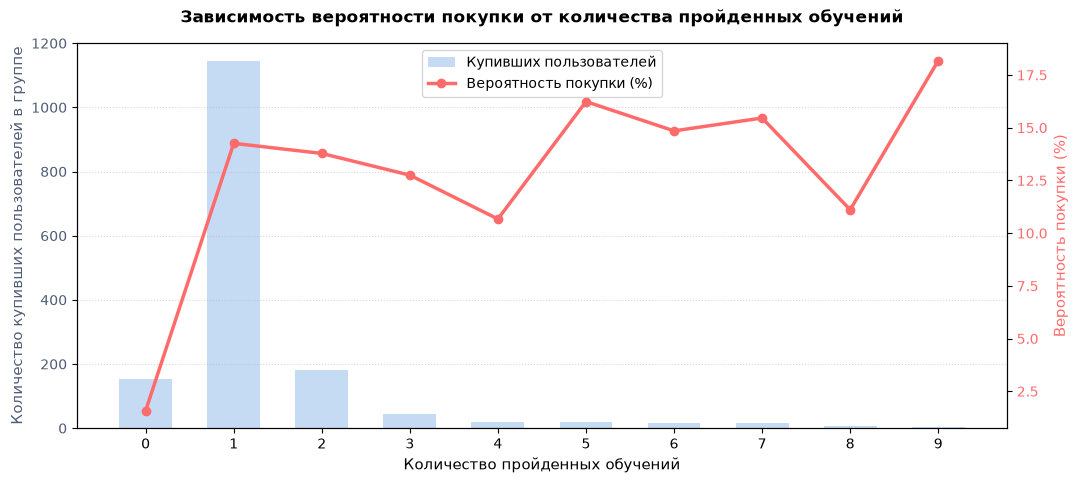

In [19]:
# 1. Задаем размер полотна
fig, ax1 = plt.subplots(figsize=(12, 5))

# --- ЛЕВАЯ ОСЬ Y: Количество пользователей (Столбчатая диаграмма) ---
color_bar = '#abcdef'  
ax1.bar(
    analysis_result['finished_tutorials_count'], 
    analysis_result['purchasers'], 
    color=color_bar, alpha=0.7, width=0.6, label='Купивших пользователей'
)
ax1.set_xlabel('Количество пройденных обучений', fontsize=11)
ax1.set_ylabel('Количество купивших пользователей в группе', color='#4f5d75', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4f5d75')
ax1.set_xticks(analysis_result['finished_tutorials_count'])

# --- ПРАВАЯ ОСЬ Y: Вероятность покупки (Линейный график) ---
ax2 = ax1.twinx()  
color_line = '#ff6b6b'  
ax2.plot(
    analysis_result['finished_tutorials_count'], 
    analysis_result['purchase_probability'], 
    color=color_line, marker='o', linewidth=2.5, label='Вероятность покупки (%)'
)
ax2.set_ylabel('Вероятность покупки (%)', color=color_line, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title('Зависимость вероятности покупки от количества пройденных обучений', fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.5, axis='y')

# 3. Совмещаем легенды от двух разных осей в одну
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center')

plt.show()

* **Игроки, которые прошли обучение 1 раз** — это главное ядро игры и те, кто приносит продукту основные деньги. Эта группа совершила абсолютный максимум — **1143 покупки**.
* **Игроки, которые вообще не проходили обучение (0 раз)** — их в игре очень много, это самая массовая группа. И хотя покупает среди них всего 1.6% людей, за счет огромного общего количества они смогли принести игре 153 покупки.
* **Игроки, которые проходили обучение 2, 3 и более раз** — таких пользователей в игре мало. Количество покупок там стремительно падает со 182 штук до единичных случаев. 

**Главный вывод:**
То, что проценты конверсии после первого обучения начинают странно прыгать (то растут, то падают) — это обычная случайность. Когда в группе мало человек, даже один случайный платеж сильно искажает общую статистику. 

Для бизнеса важен только один простой факт: прошел игрок обучение хотя бы один раз или не проходил вообще. Повторные прохождения инструкций уже никак не влияют на желание пользователей тратить деньги в игре.

### 4.3 Статистический тест

Из таблицы и графика видно, что доля покупателей в группах сильно отличается. Проведем строгую математическую проверку.
Для этого мы используем критерий Хи-квадрат Пирсона. Это стандартный тест, который позволяет узнать, зависит ли один факт (совершил ли человек покупку) от другого (сколько раз он проходил обучение).

In [20]:
# 1. Формируем таблицу сопряженности. Сколько в каждой группе купили, а сколько НЕ купили
contingency_table = np.array([
    analysis_result['purchasers'],                                    # Строка 1: Количество покупателей
    analysis_result['total_users'] - analysis_result['purchasers']   # Строка 2: Количество НЕ покупателей
]).T # Транспонируем, чтобы группы шли по строкам

# 2. Запускаем тест Хи-квадрат
_, p_value, _, _ = stats.chi2_contingency(contingency_table)

print(f"p-value: {p_value:}")
print(f"Вердикт: {'ОТКЛОНЯЕМ H0 (Зависимость статистически значима)' if p_value < 0.05 else 'НЕ ОТКЛОНЯЕМ H0 (Разницы нет)'}")

p-value: 1.294564515855701e-223
Вердикт: ОТКЛОНЯЕМ H0 (Зависимость статистически значима)


**Итог математической проверки:**  
Тест выдал значение `p-value`, практически равное нулю. Наблюдаемая разница статистически значима и не случайна. Прохождение обучения положительно влияет на вероятность покупки.

**Вывод:**  
Прохождение обучения — это важный коммерческий этап для игры. Сам факт успешного завершения хотя бы одного обучения увеличивает шансы на покупку **почти в 10 раз (с 1.6% до 14.3%)**. При этом заставлять пользователя проходить обучение повторно экономически бессмысленно — никакого дополнительного прироста доходов это игре не приносит.

## 5. Как часто пользователи начинают обучение после выбора уровня сложности.  

В идеальном сценарии пользователь один раз знакомится с правилами, а затем линейно движется вперед по игре. Но если игрок уже выбрал уровень сложности и готов играть, но вдруг возвращается назад к инструкциям — это важный сигнал. Возможно, он столкнулся с чем-то непонятным.

Ниже мы проверим, как часто пользователи запускают обучение уже после того, как сделали свой самый первый выбор уровня сложности.

### 5.1. Расчёты

In [21]:
# 1. Находим время самого первого выбора уровня сложности для каждого пользователя.
first_level_choice = (
    events[events['event_type'] == 'level_choice']
    .groupby('user_id')['start_time']
    .min()
)

# 2. Находим время всех стартов обучения
tut_starts = events[events['event_type'] == 'tutorial_start']

# 3. Присоединяем к каждому старту обучения время первого выбора уровня сложности этого пользователя.
tut_starts = tut_starts.copy()
tut_starts['first_level_choice_time'] = tut_starts['user_id'].map(first_level_choice)

# 4. Ищем строки, где обучение началось позже, чем был выбран уровень сложности
late_tutorials = tut_starts[tut_starts['start_time'] > tut_starts['first_level_choice_time']]

# 5. Считаем метрики для бизнес-отчета
total_cohort_users = len(cohort_2018_users)
users_with_late_tut = late_tutorials['user_id'].nunique()
share_late_users = (users_with_late_tut / total_cohort_users) * 100

print(f"Всего пользователей: {total_cohort_users}")
print(f"Пользователей, вернувшихся к обуению: {users_with_late_tut}")
print(f"Доля таких пользователей: {share_late_users:.2f}%")

Всего пользователей: 19926
Пользователей, вернувшихся к обуению: 1386
Доля таких пользователей: 6.96%


### 5.2. Масштаб проблемы и рекомендации для бизнеса

**Результаты расчета:**
* Всего вернулись к обучению после выбора уровня сложности: **1386 игроков**.
* Это составляет **6.96%** от всей исследуемой группы пользователей 2018 года.

**Главный вывод:**  
Доля почти в 7% — это высокий показатель для мобильной игры. Он подтверждает, что в интерфейсе или правилах самой игры есть что-то, вызывающее непонимание. Игроки готовы играть, но, оказавшись на главном экране, теряются (например, не понимают логику подсказок, таймера или начисления очков) и вынуждены использовать обучение как «интерактивную справку». При этом им не обязательно доходить в обучении до конца — они находят ответ на свой точечный вопрос и закрывают его.

**Рекомендации к дальнейшим действиям:**
1. **Улучшить игровой экран:** Передать эти данные дизайнерам и разработчикам. Вместо того чтобы вынуждать пользователя полностью перезапускать обучение, стоит добавить короткие всплывающие подсказки (знаки вопроса или подсказки по нажатию) прямо на те элементы экрана, которые вызывают вопросы.
2. **Изучить уходы из игры:** В рамках следующего исследования нужно проверить, как этот барьер влияет на отток игроков. Помогает ли им этот вынужденный возврат в обучение остаться в игре, или они закрывают приложение от раздражения и больше никогда не возвращаются.